# Two-Layer Neural Network Implementation – Image Classification (Cars vs Bikes)

## Problem Statement

Refer to the provided folder structure containing image data organized into two classes:  

- **Cars**
- **Bikes**

Examine the directory structure carefully before beginning the implementation.

---

## Data Preprocessing Requirements

Perform the following steps:

1. **Load Data**
   - Read all RGB images from both class folders.

2. **Resize Images**
   - Resize each image to a fixed dimension (e.g., 64 × 64).

3. **Normalize Pixel Values**
   - Scale pixel values to the range [0, 1].

4. **Flatten Images**
   - Convert each image into a 1D vector suitable as input to a fully connected neural network.

5. **Assign Labels**
   - Assign binary labels:
     - `0` → Cars  
     - `1` → Bikes  

6. **Shuffle and Split Dataset**
   - Combine data from both classes.
   - Shuffle the dataset randomly.
   - Split the dataset into:
     - 80% Training set
     - 20% Testing set

---

In [2]:
import numpy as np
import os
from PIL import Image

In [3]:
def load_and_preprocess(car_dir, bike_dir, size=(64, 64)):
    data = []
    labels = []
    
    # Label 0: Cars, Label 1: Bikes
    configs = [(car_dir, 0), (bike_dir, 1)]
    
    for folder, label in configs:
        for filename in os.listdir(folder):
            if filename.lower().endswith('.bmp'):
                img = Image.open(os.path.join(folder, filename)).convert('RGB')
                img = img.resize(size)
                # Flatten and Normalize
                data.append(np.array(img).flatten() / 255.0) 
                labels.append(label)
    
    X = np.array(data).T  # Shape: (features, m)
    Y = np.array(labels).reshape(1, -1)
    
    # Shuffle and Split (80% Train, 20% Test)
    m = X.shape[1]
    permutation = np.random.permutation(m)
    X, Y = X[:, permutation], Y[:, permutation]
    
    split_idx = int(m * 0.8)
    X_train, X_test = X[:, :split_idx], X[:, split_idx:]
    Y_train, Y_test = Y[:, :split_idx], Y[:, split_idx:]
    
    return X_train, Y_train, X_test, Y_test

In [4]:
# Update these paths to your folder names
X_train, Y_train, X_test, Y_test = load_and_preprocess('transport/cars', 'transport/bike')

## Model Design: Two-Layer Neural Network

Design a neural network with:

- **Input Layer**
  - Size = number of features (flattened image size).

- **Hidden Layer**
  - One hidden layer.
  - Use a suitable activation function (e.g., ReLU or Sigmoid).

- **Output Layer**
  - Single neuron for binary classification.
  - Use Sigmoid activation function.

---

In [6]:
class TwoLayerNetwork:
    def __init__(self, n_x, n_h, n_y):
        # He Initialization
        self.W1 = np.random.randn(n_h, n_x) * np.sqrt(2/n_x)
        self.b1 = np.zeros((n_h, 1))
        self.W2 = np.random.randn(n_y, n_h) * np.sqrt(2/n_h)
        self.b2 = np.zeros((n_y, 1))

    def forward(self, X):
        Z1 = np.dot(self.W1, X) + self.b1
        A1 = np.maximum(0, Z1) # ReLU
        Z2 = np.dot(self.W2, A1) + self.b2
        A2 = 1 / (1 + np.exp(-Z2)) # Sigmoid
        cache = {"Z1": Z1, "A1": A1, "Z2": Z2, "A2": A2}
        return A2, cache

    def backward(self, X, Y, cache):
        m = X.shape[1]
        A1, A2 = cache["A1"], cache["A2"]
        Z1 = cache["Z1"]

        # Output layer gradients
        dZ2 = A2 - Y
        dW2 = (1/m) * np.dot(dZ2, A1.T)
        db2 = (1/m) * np.sum(dZ2, axis=1, keepdims=True)

        # Hidden layer gradients
        dA1 = np.dot(self.W2.T, dZ2)
        dZ1 = dA1 * (Z1 > 0) # ReLU derivative
        dW1 = (1/m) * np.dot(dZ1, X.T)
        db1 = (1/m) * np.sum(dZ1, axis=1, keepdims=True)

        return {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}

    def update(self, grads, lr):
        self.W1 -= lr * grads["dW1"]
        self.b1 -= lr * grads["db1"]
        self.W2 -= lr * grads["dW2"]
        self.b2 -= lr * grads["db2"]

## Training Process

Train the model using:

- Forward Propagation
- Backpropagation
- Optimization algorithm (e.g., Gradient Descent or its variants)
- Binary Cross-Entropy Loss

Train the model for a fixed number of epochs while:

- Monitoring training loss
- Recording loss values per epoch

---

## Evaluation

After training:

1. Generate predictions on:
   - Training dataset
   - Testing dataset

2. Compute:
   - Training Accuracy
   - Testing Accuracy

3. Plot:
   - Loss vs Epochs graph

---

## Expected Output

- Report final training accuracy.
- Report final testing accuracy.
- Display the loss vs epochs curve.

In [8]:
import matplotlib.pyplot as plt

# Hyperparameters
n_x = X_train.shape[0] # Features
n_h = 64               # Hidden units
n_y = 1                # Output
learning_rate = 0.005
epochs = 3000

model = TwoLayerNetwork(n_x, n_h, n_y)
costs = []

for i in range(epochs):
    AL, cache = model.forward(X_train)
    
    # Binary Cross-Entropy Loss
    cost = -np.mean(Y_train * np.log(AL + 1e-8) + (1 - Y_train) * np.log(1 - AL + 1e-8))
    costs.append(cost)
    
    grads = model.backward(X_train, Y_train, cache)
    model.update(grads, learning_rate)
    
    if i % 500 == 0:
        print(f"Epoch {i}, Loss: {cost:.4f}")

Epoch 0, Loss: 0.8948
Epoch 500, Loss: 0.4964
Epoch 1000, Loss: 0.4159
Epoch 1500, Loss: 0.3431
Epoch 2000, Loss: 0.2834
Epoch 2500, Loss: 0.2217


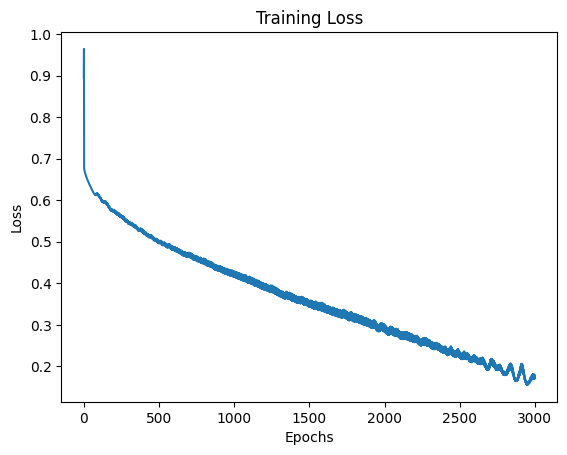

In [9]:
# Plotting Loss vs Epochs
plt.plot(costs)
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.title("Training Loss")
plt.show()

In [10]:
def get_accuracy(X, Y, model, dataset_name):
    probas, _ = model.forward(X)
    predictions = (probas > 0.5).astype(int)
    accuracy = np.mean(predictions == Y) * 100
    print(f"{dataset_name} Accuracy: {accuracy:.2f}%")

get_accuracy(X_train, Y_train, model, "Training")
get_accuracy(X_test, Y_test, model, "Testing")

Training Accuracy: 95.70%
Testing Accuracy: 71.34%
